In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
import cmocean as cm
from datetime import timedelta, timezone
import textalloc as ta
from sklearn.linear_model import HuberRegressor


from jiflr import ROOT
from jiflr.data import select_sensors, merge_sensor_datasets
from jiflr.utils import get_sunrise_sunset, lapse_rate_ufunc
from jiflr.pdd import get_theoretical_pdd, pdd_from_datetimes, sum_observed_pdds, pdd


In [2]:
# Load pendant data
ds_pendants = xr.open_dataset(ROOT / "data/2025/processed/lvl1/lvl1_on_ice.nc")
ds_pendants = select_sensors(ds_pendants, height="2m", shielding="shielded")

# Load intensive site data and filter to shielded pendants
ds_intensive = xr.open_dataset(
    ROOT / "data/2025/processed/lvl1/lvl1_on_ice_intensive.nc"
)
ds_intensive = select_sensors(ds_intensive, height="2m", shielding="shielded")

# Merge datasets
ds = merge_sensor_datasets(ds_pendants, ds_intensive)

# resample to 15 min
da = ds.temp_c.resample(datetime="15min").mean(skipna=True)
da = da.dropna(dim="datetime", how="all")

da

<xarray.DataArray 'temp_c' (datetime: 5502, sensor_idx: 30)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(5502, 30))
Coordinates:
  * datetime           (datetime) datetime64[ns] 44kB 2025-06-11T16:45:00 ......
  * sensor_idx         (sensor_idx) int64 240B 0 1 2 3 4 5 ... 24 25 26 27 28 29
    sensor_id          (sensor_idx) <U8 960B '22133648' ... '22133654'
    site_id            (sensor_idx) <U9 1kB 'G01' 'D02' ... 'Lee1' 'Divide'
    height             (sensor_idx) <U2 240B '2m' '2m' '2m' ... '2m' '2m' '2m'
    shielding          (sensor_idx) <U10 1kB 'shielded' ... 'shielded'
    sensor_type        (sensor_idx) <U12 1kB 'hobo pendant' ... 'hobo pendant'
    sensor_generation  (sensor_idx) <U3 360B 'new' 'new' 'new' ... 'new' 'new'
    elevation          (sensor_idx) float64 240B 1.128e+03 ... 1.858e+03
    latitude           (sensor_idx) float64 240B 58.62 58.68 ... 58.94 58.86
    longitude          (sensor_idx) float64 240B -134.3 -134.4 ... -134.1 -134.2
Attributes:
    sensor_type:         hobo pendant
    sensor_generation:   new
    sensor_id:           22133648
    tz:                  America/Anchorage
    temp_unit_original:  C
    site_name:           G01
    sensor_height:       2m
    sensor_config:       
    shielding:           shielded
    structure:           sensor_idx × datetime

# Mask by daylight hours

In [3]:
# Extract the datetime index from the DataArray
utc_offset = da["datetime"].attrs["utc_offset_hours"]  # -9.0
tz = timezone(timedelta(hours=utc_offset))
dt_index = da["datetime"].to_index().tz_localize(tz)

# Generate sunrise/sunset table
sun_df = get_sunrise_sunset(dt_index)

# Create and apply mask
is_daylight = (dt_index >= sun_df["sunrise"]) & (dt_index <= sun_df["sunset"])
daylight_mask = xr.DataArray(
    is_daylight, coords={"datetime": da.datetime}, dims=["datetime"]
)
da_daylight = da.where(daylight_mask)

<xarray.DataArray 'temp_c' ()> Size: 8B
array(5.21767433)
<xarray.DataArray 'temp_c' ()> Size: 8B
array(4.57518652)


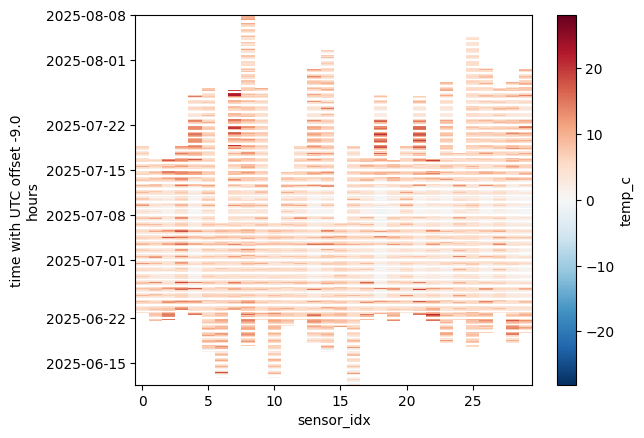

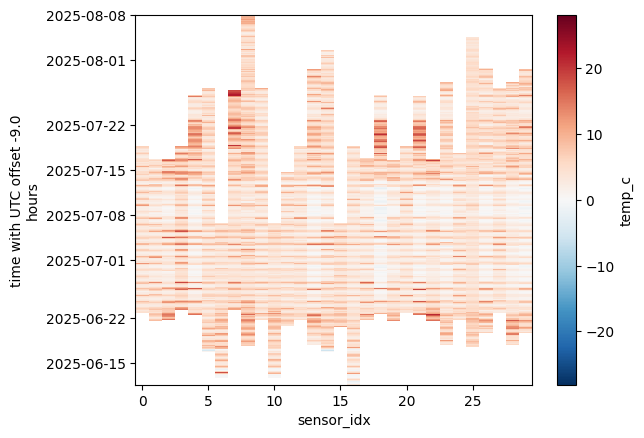

In [4]:
# Check that the output is correct

fig, ax = plt.subplots()
da_daylight.plot(ax=ax)

fig, ax = plt.subplots()
da.plot(ax=ax)

print(da_daylight.mean())
print(da.mean())

# Calculate degree days for 3 different critera and 3 different periods
## Criteria
1. Only during daylight hours
2. During all hours
3. During all hours, but only counting temperatures above 2 degC during nighttime

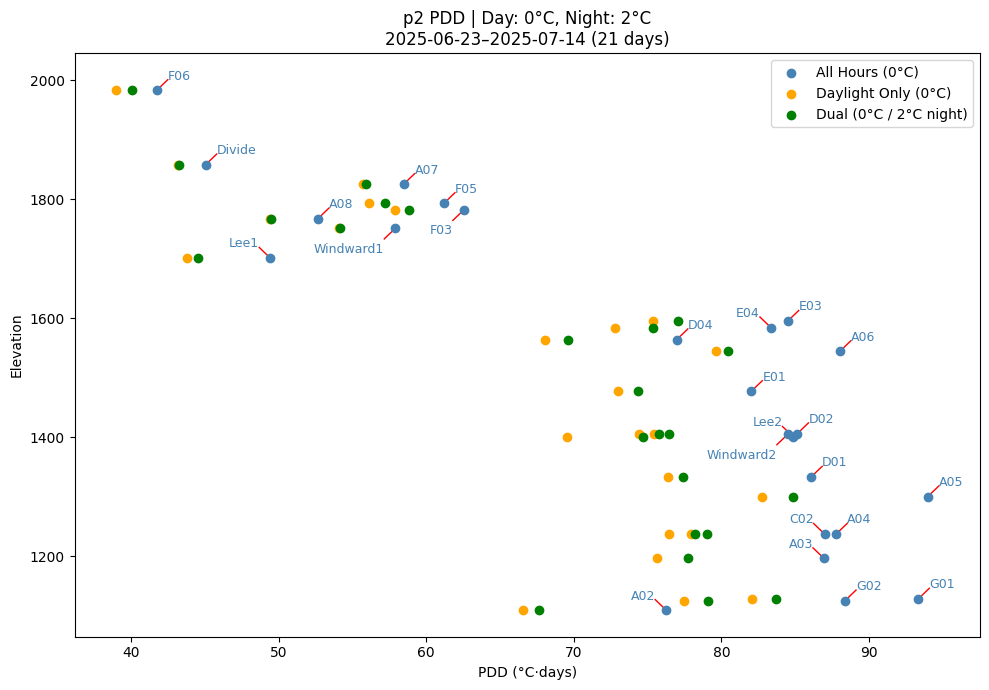

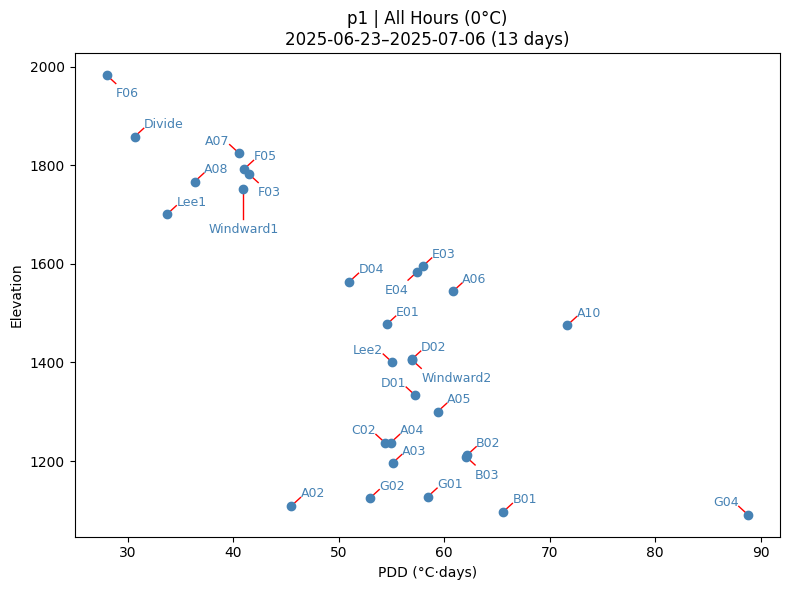

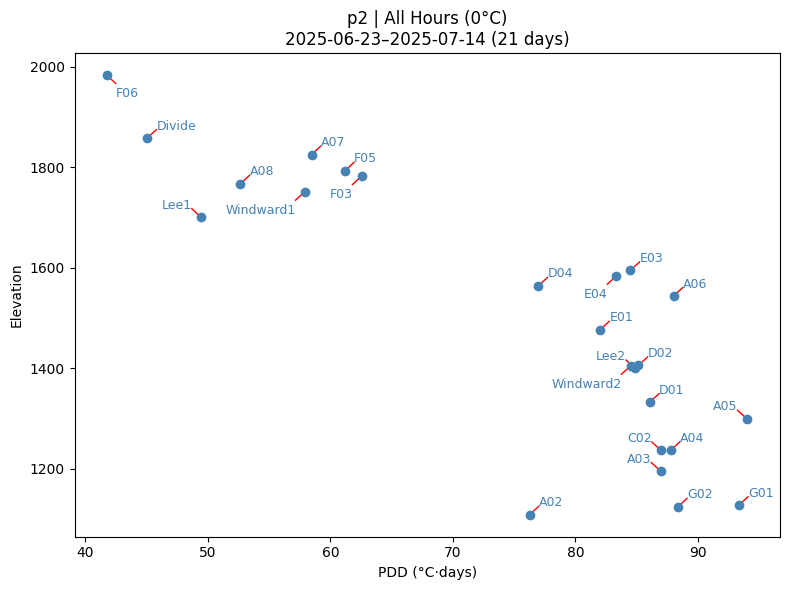

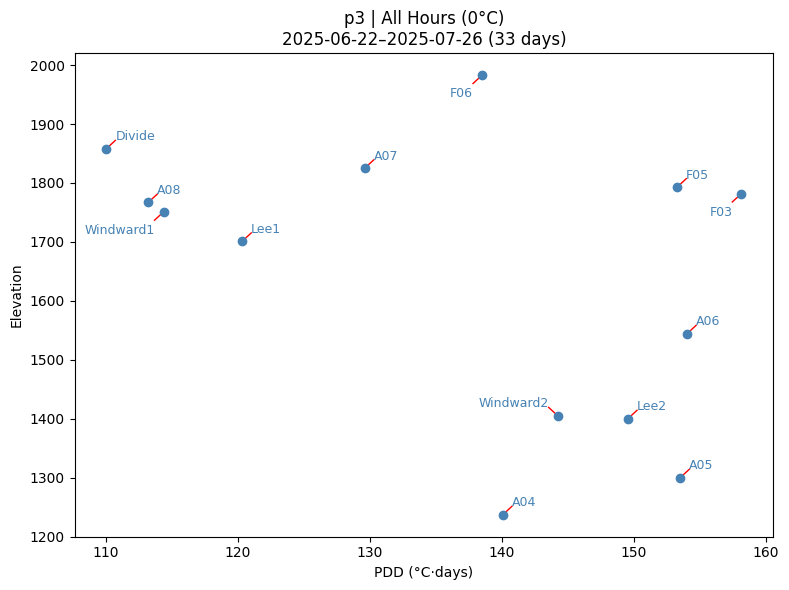

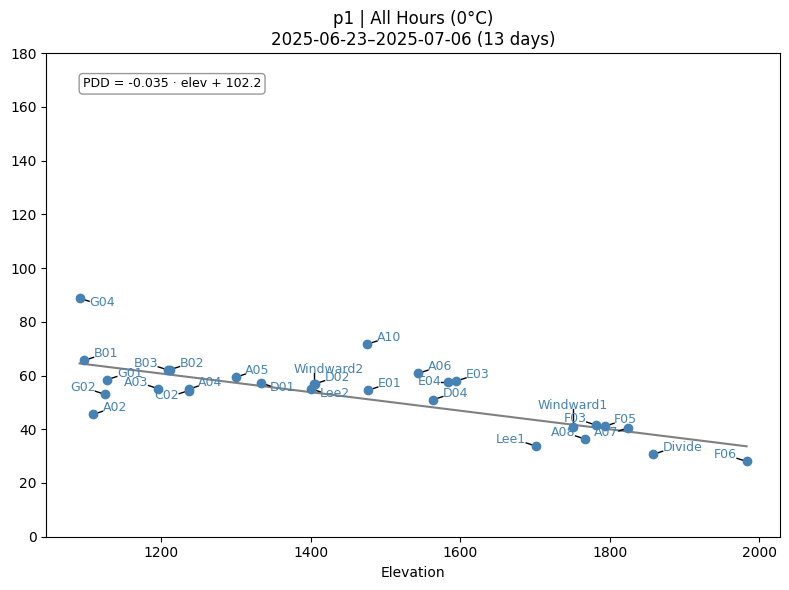

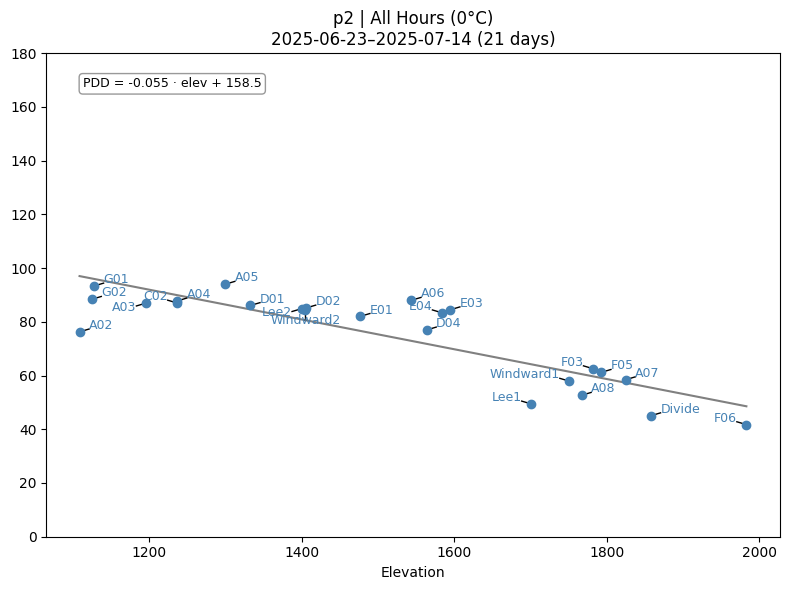

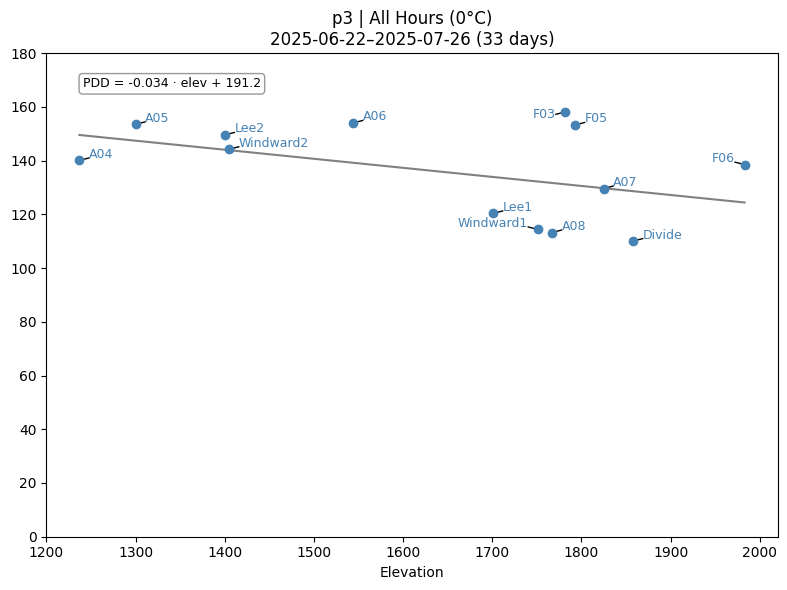

In [5]:
# ── Config ────────────────────────────────────────────────────────────────────
DAY_THRESHOLD = 0
NIGHT_THRESHOLD = 2

CRITERIA_PERIOD = "p2"
SINGLE_CRITERION = "all"

P3_SITES = [
    "A04",
    "A05",
    "Windward2",
    "A06",
    "Windward1",
    "F03",
    "F05",
    "F06",
    "A07",
    "Divide",
    "A08",
    "Lee1",
    "Lee2",
]


# ── Period/criterion helpers ──────────────────────────────────────────────────
def get_period_arrays(period):
    """Return (da_full, da_day) for a given period name."""
    masks = {
        "p1": None,
        "p2": (~da.site_id.str.startswith("B")) & (~da.site_id.isin(["A10", "G04"])),
        "p3": da.site_id.isin(P3_SITES),
    }
    mask = masks[period]
    if mask is None:
        return da, da_daylight
    return da.sel(sensor_idx=mask), da_daylight.sel(sensor_idx=mask)


def _period_date_info(da_period):
    """Return (start_str, end_str, n_days) for the overlap window of da_period."""
    has_data = da_period.notnull().all(dim="sensor_idx")
    da_overlap = da_period.sel(datetime=has_data)
    t0 = pd.Timestamp(da_overlap.datetime.values[0])
    t1 = pd.Timestamp(da_overlap.datetime.values[-1])
    return t0.strftime("%Y-%m-%d"), t1.strftime("%Y-%m-%d"), (t1 - t0).days


# ── PDD computation ───────────────────────────────────────────────────────────
def get_overlap_pdd(da_period, threshold=0):
    """Single-threshold PDD over the shared overlap window."""
    has_data = da_period.notnull().all(dim="sensor_idx")
    da_overlap = da_period.sel(datetime=has_data)
    da_threshold = da_overlap.where(da_overlap > threshold, 0)
    df = sum_observed_pdds(da_threshold).to_frame()
    elev = (
        da_period.to_dataframe(name="temp_c")
        .reset_index()[["site_id", "elevation"]]
        .drop_duplicates("site_id")
        .set_index("site_id")["elevation"]
    )
    return df.drop(columns=["elevation"], errors="ignore").join(elev)


def get_overlap_pdd_dual(
    da_full, da_day, day_thresh=DAY_THRESHOLD, night_thresh=NIGHT_THRESHOLD
):
    """Dual-threshold PDD (separate thresholds for day vs night)."""
    has_data = da_full.notnull().all(dim="sensor_idx")
    da_full_overlap = da_full.sel(datetime=has_data)
    da_day_overlap = da_day.sel(datetime=da_full_overlap.datetime)
    is_daytime = da_day_overlap.notnull()

    pdd_day = (
        da_full_overlap.where(is_daytime)
        .where(da_full_overlap > day_thresh, 0)
        .sum(dim="datetime")
    )
    pdd_night = (
        (da_full_overlap - night_thresh)
        .where(~is_daytime)
        .where(da_full_overlap > night_thresh, 0)
        .sum(dim="datetime")
    )

    dti = pd.DatetimeIndex(da_full_overlap.datetime.values)
    step_days = (dti[1] - dti[0]).total_seconds() / 86_400.0
    da_pdd = (pdd_day + pdd_night) * step_days

    df = pd.Series(da_pdd.values, index=da_full.site_id.values, name="pdd").to_frame()
    elev = (
        da_full.to_dataframe(name="temp_c")
        .reset_index()[["site_id", "elevation"]]
        .drop_duplicates("site_id")
        .set_index("site_id")["elevation"]
    )
    return df.join(elev)


def _fetch_criterion(period, criterion):
    """Fetch PDD DataFrame for a single period/criterion combination."""
    da_full, da_day = get_period_arrays(period)
    if criterion == "dual":
        df = get_overlap_pdd_dual(da_full, da_day)
        label = f"Dual ({DAY_THRESHOLD}°C day / {NIGHT_THRESHOLD}°C night)"
        color = "green"
    elif criterion == "all":
        df = get_overlap_pdd(da_full, threshold=0)
        label, color = "All Hours (0°C)", "steelblue"
    else:  # "daylight"
        df = get_overlap_pdd(da_day, threshold=DAY_THRESHOLD)
        label, color = "Daylight Only (0°C)", "orange"
    return df, label, color


# ── Plot 1: All criteria for a single chosen period ───────────────────────────
def plot_criteria_comparison(period):
    da_full, da_day = get_period_arrays(period)
    start, end, n_days = _period_date_info(da_full)

    criteria = {
        "All Hours (0°C)": (get_overlap_pdd(da_full, threshold=0), "steelblue"),
        "Daylight Only (0°C)": (
            get_overlap_pdd(da_day, threshold=DAY_THRESHOLD),
            "orange",
        ),
        f"Dual ({DAY_THRESHOLD}°C / {NIGHT_THRESHOLD}°C night)": (
            get_overlap_pdd_dual(da_full, da_day),
            "green",
        ),
    }

    fig, ax = plt.subplots(figsize=(10, 7))
    all_x = np.concatenate([r[0].pdd.values for r in criteria.values()])
    all_y = np.concatenate([r[0].elevation.values for r in criteria.values()])

    for i, (label, (df, color)) in enumerate(criteria.items()):
        ax.scatter(df.pdd, df.elevation, color=color, zorder=3, label=label)
        if i == 0:
            ta.allocate(
                ax,
                df.pdd.values,
                df.elevation.values,
                df.index.tolist(),
                x_scatter=all_x,
                y_scatter=all_y,
                textsize=9,
                textcolor=color,
            )

    ax.set_xlabel("PDD (°C·days)")
    ax.set_ylabel("Elevation")
    ax.set_title(
        f"{period} PDD | Day: {DAY_THRESHOLD}°C, Night: {NIGHT_THRESHOLD}°C\n"
        f"{start}–{end} ({n_days} days)"
    )
    ax.legend()
    plt.tight_layout()
    plt.show()


# ── Plot 2: One period per plot, single criterion ─────────────────────────────
def plot_period_comparison(criterion=SINGLE_CRITERION):
    for period in ("p1", "p2", "p3"):
        df, label, color = _fetch_criterion(period, criterion)
        da_full, _ = get_period_arrays(period)
        start, end, n_days = _period_date_info(da_full)

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(df.pdd, df.elevation, color=color, zorder=3)
        ta.allocate(
            ax,
            df.pdd.values,
            df.elevation.values,
            df.index.tolist(),
            x_scatter=df.pdd.values,
            y_scatter=df.elevation.values,
            textsize=9,
            textcolor=color,
        )
        ax.set_xlabel("PDD (°C·days)")
        ax.set_ylabel("Elevation")
        ax.set_title(f"{period} | {label}\n{start}–{end} ({n_days} days)")
        plt.tight_layout()
        plt.show()


# ── Plot 3: Huber regression for all periods, single criterion ────────────────
def plot_huber_regression(criterion=SINGLE_CRITERION):
    for period in ("p1", "p2", "p3"):
        df, label, color = _fetch_criterion(period, criterion)
        da_full, _ = get_period_arrays(period)
        start, end, n_days = _period_date_info(da_full)

        df_plot = df[["pdd", "elevation"]].dropna()
        x, y = df_plot.elevation.values, df_plot.pdd.values

        huber = HuberRegressor().fit(x.reshape(-1, 1), y)
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = huber.predict(x_line.reshape(-1, 1))

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(x, y, color=color, zorder=3)
        ax.plot(x_line, y_line, color="gray", lw=1.5, zorder=2)
        ta.allocate(
            ax,
            x,
            y,
            df_plot.index.tolist(),
            x_scatter=x,
            y_scatter=y,
            textsize=9,
            textcolor=color,
            linecolor="black",
        )
        ax.annotate(
            f"PDD = {huber.coef_[0]:.3f} · elev + {huber.intercept_:.1f}",
            xy=(0.05, 0.95),
            xycoords="axes fraction",
            fontsize=9,
            va="top",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
        )
        ax.set_xlabel("Elevation")
        ax.set_ylim(0, 180)
        ax.set_title(f"{period} | {label}\n{start}–{end} ({n_days} days)")
        plt.tight_layout()
        plt.show()


# ── Run ───────────────────────────────────────────────────────────────────────
plot_criteria_comparison(CRITERIA_PERIOD)
plot_period_comparison()
plot_huber_regression()

# Calculate theoretical degree days

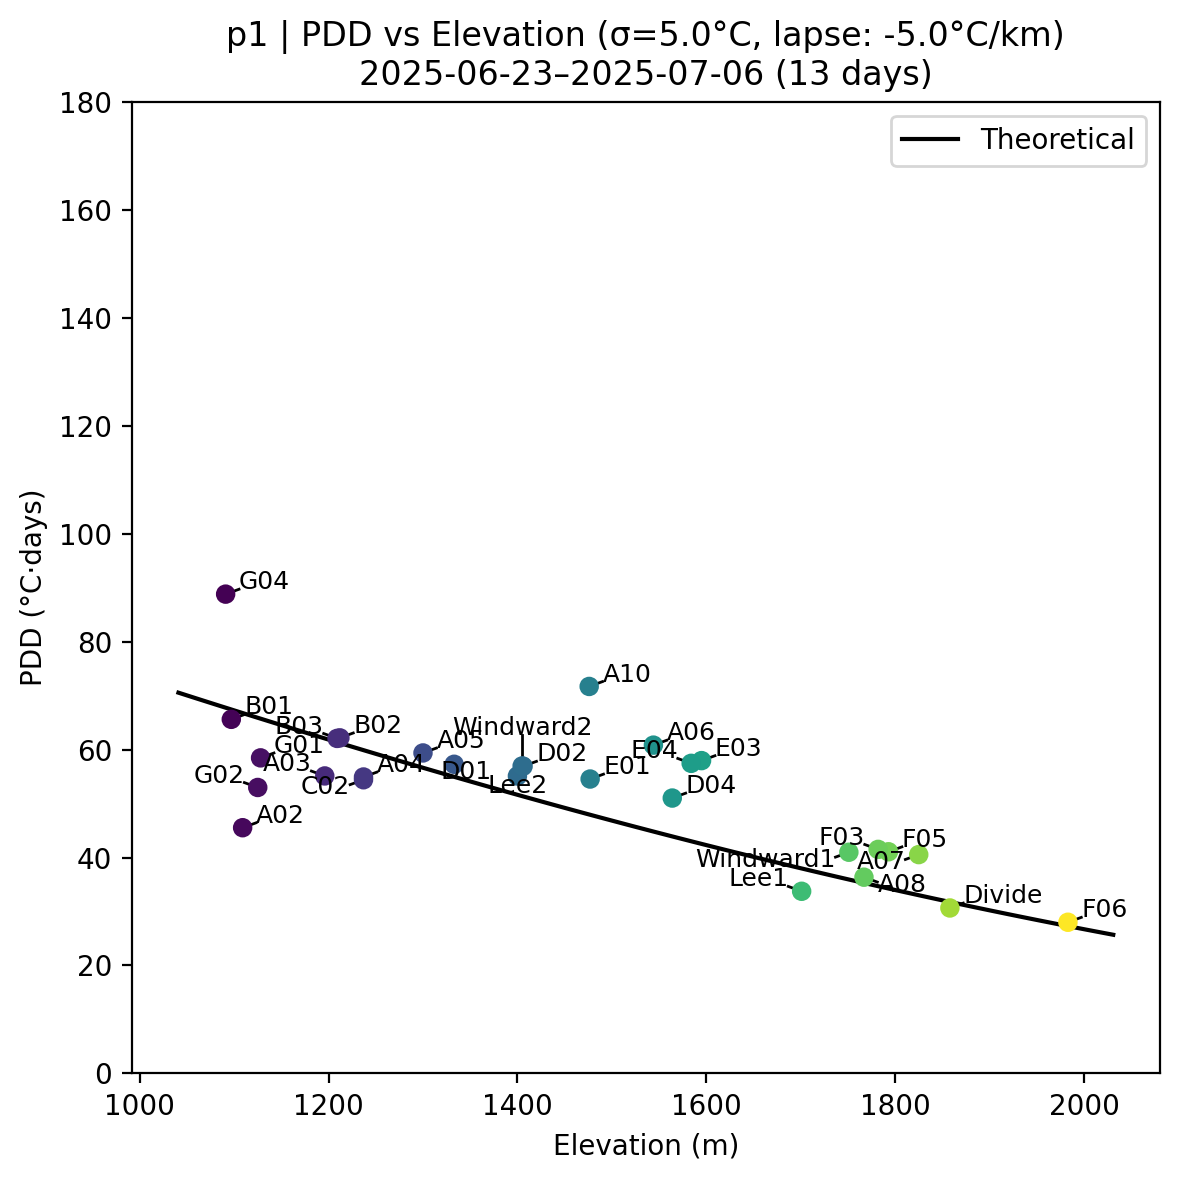

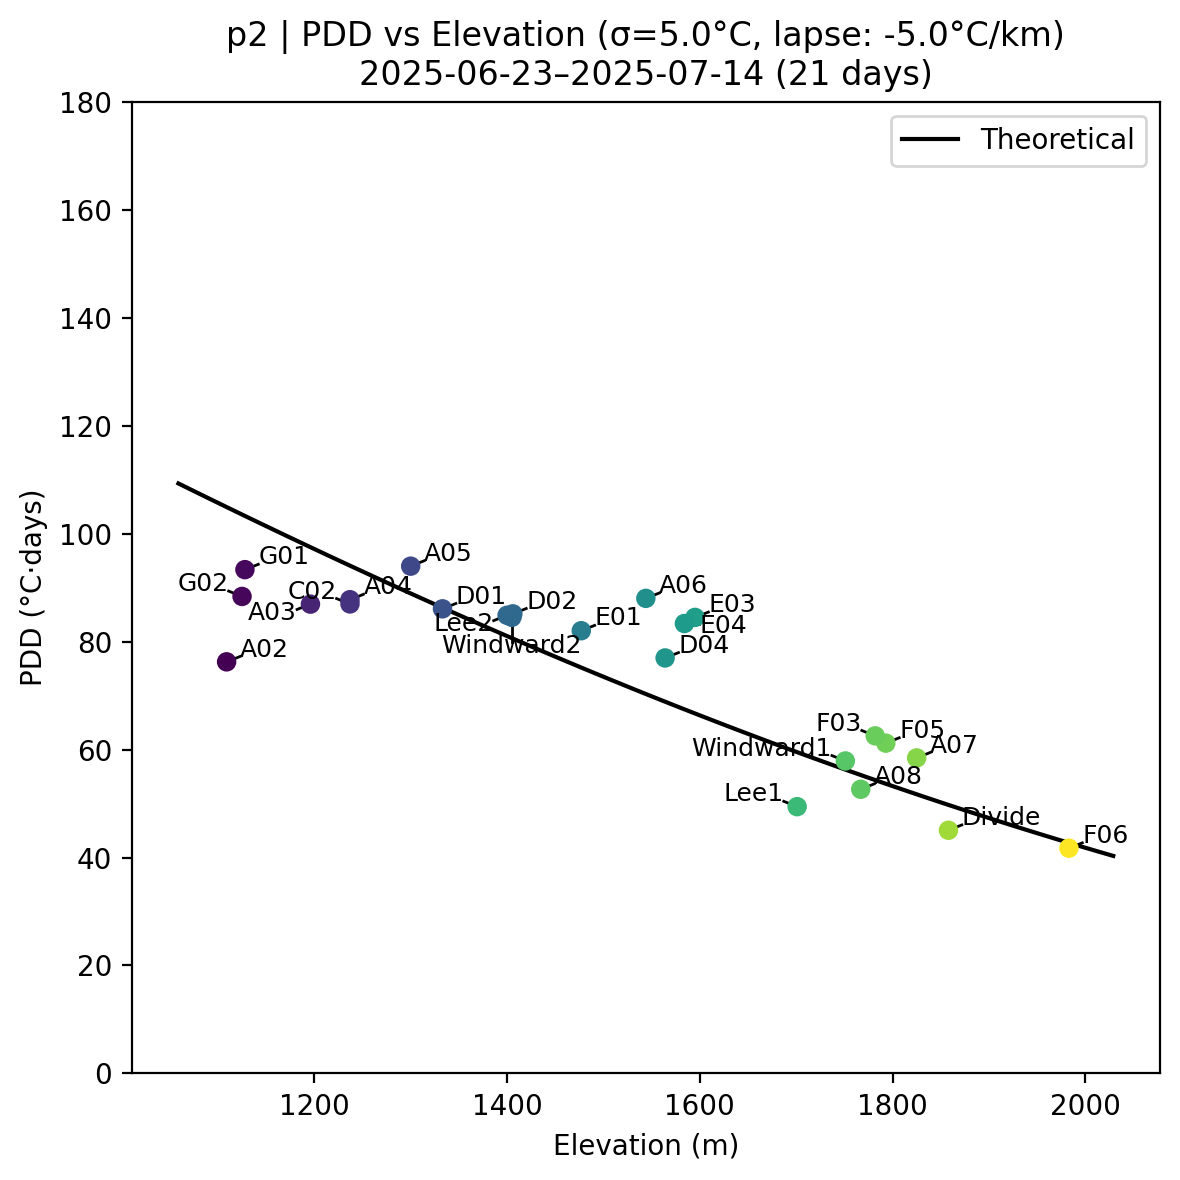

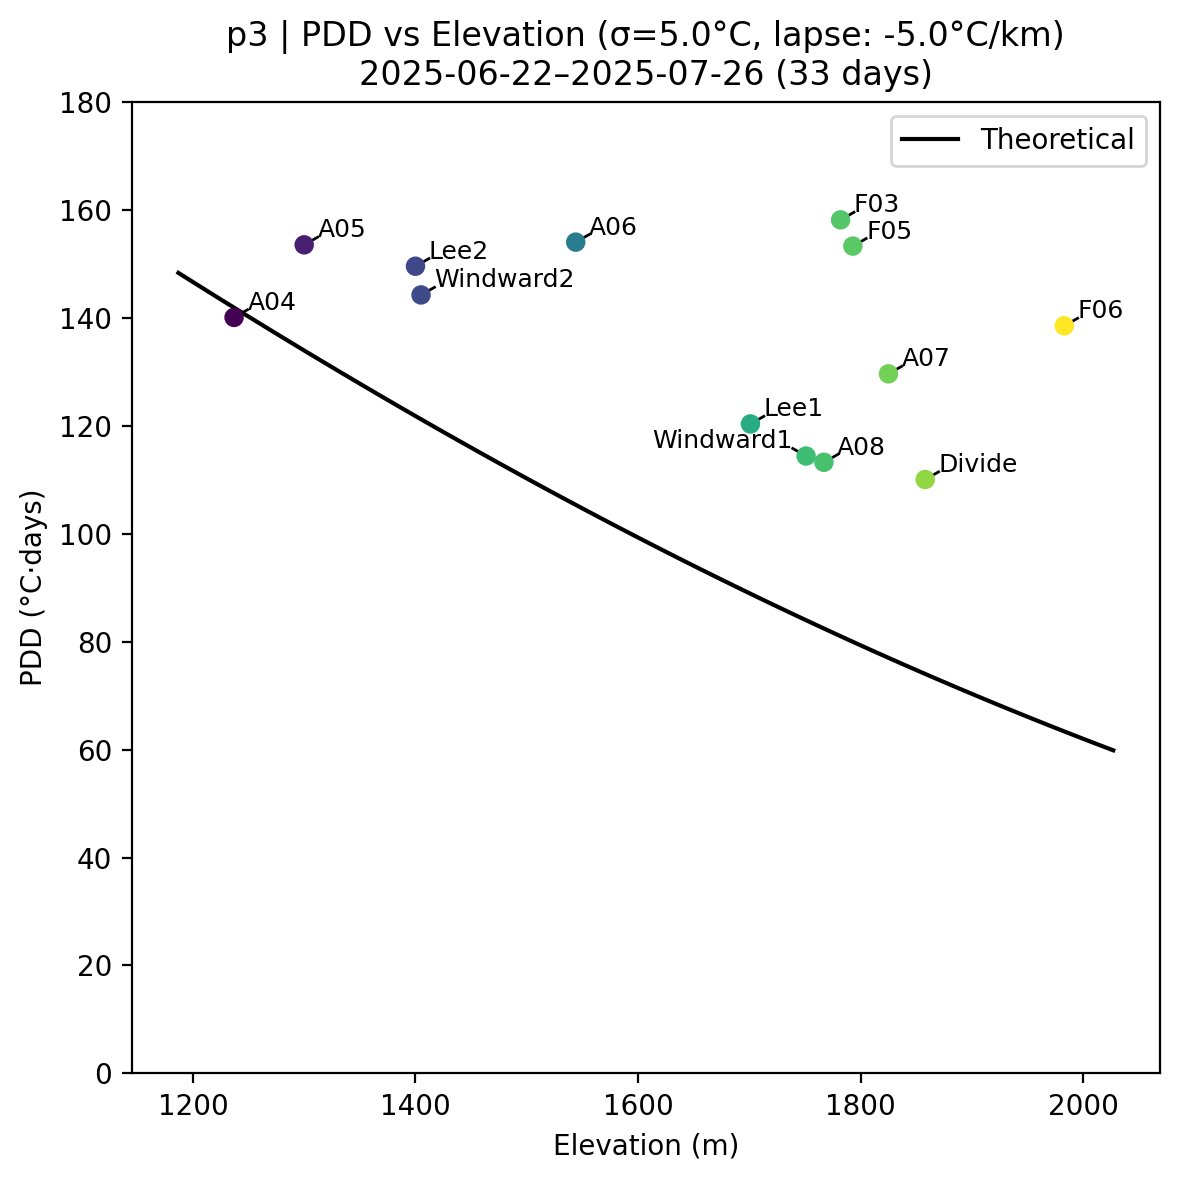

In [6]:
# ── Config ────────────────────────────────────────────────────────────────────
T_MA_0 = -5.0  # T_ma at sea level (°C)
T_MJ_0 = 10.0  # T_mj at sea level (°C)
LAPSE_T_MA = -5 / 1000  # lapse rate for T_ma (°C/m), typically -6.5°C/km
LAPSE_T_MJ = -5 / 1000  # lapse rate for T_mj (°C/m), can differ from T_ma
SIGMA = 5.0


# ── Plot 4: Theoretical vs observed PDD per period ────────────────────────────
def plot_theoretical_vs_observed(criterion=SINGLE_CRITERION):
    for period in ("p1", "p2", "p3"):
        da_full, da_day = get_period_arrays(period)
        df_obs, label, color = _fetch_criterion(period, criterion)
        start, end, n_days = _period_date_info(da_full)
        df_theo = get_theoretical_pdd(
            da_full,
            t_ma_0=T_MA_0,
            t_mj_0=T_MJ_0,
            lapse_t_ma=LAPSE_T_MA,
            lapse_t_mj=LAPSE_T_MJ,
            sigma=SIGMA,
        )

        df_plot = (
            df_obs[["pdd", "elevation"]]
            .join(df_theo[["pdd_theoretical"]], how="inner")
            .dropna()
        )

        fig, ax = plt.subplots(figsize=(8, 6))
        sc = ax.scatter(
            df_plot.pdd_theoretical,
            df_plot.pdd,
            c=df_plot.elevation,
            cmap="viridis",
            zorder=3,
        )
        plt.colorbar(sc, ax=ax, label="Elevation")

        lims = [
            min(df_plot.pdd_theoretical.min(), df_plot.pdd.min()) * 0.95,
            max(df_plot.pdd_theoretical.max(), df_plot.pdd.max()) * 1.05,
        ]
        ax.plot(lims, lims, "k--", lw=1, zorder=2, label="1:1")
        ta.allocate(
            ax,
            df_plot.pdd_theoretical.values,
            df_plot.pdd.values,
            df_plot.index.tolist(),
            x_scatter=df_plot.pdd_theoretical.values,
            y_scatter=df_plot.pdd.values,
            textsize=9,
        )
        ax.set_xlabel("Theoretical PDD (°C·days)")
        ax.set_ylabel(f"Observed PDD — {label}")
        ax.set_title(
            f"{period} | Theoretical (σ={SIGMA}°C) vs Observed\n"
            f"{start}–{end} ({n_days} days)"
        )
        ax.legend()
        plt.tight_layout()
        plt.show()


# ── Plot 5: PDD vs elevation per period ───────────────────────────────────────
def plot_pdd_vs_elevation(criterion=SINGLE_CRITERION):
    for period in ("p1", "p2", "p3"):
        da_full, _ = get_period_arrays(period)
        df_obs, label, color = _fetch_criterion(period, criterion)
        start, end, n_days = _period_date_info(da_full)

        # Overlap datetimes — same window used by get_theoretical_pdd
        has_data = da_full.notnull().all(dim="sensor_idx")
        overlap_dti = pd.DatetimeIndex(da_full.sel(datetime=has_data).datetime.values)

        df_plot = df_obs[["pdd", "elevation"]].dropna()

        elev_range = np.arange(
            int(df_plot.elevation.min()) - 50,
            int(df_plot.elevation.max()) + 50,
            10,
        )
        theo_line = np.array(
            [
                pdd_from_datetimes(
                    overlap_dti,
                    T_ma=T_MA_0 + LAPSE_T_MA * e,
                    T_mj=T_MJ_0 + LAPSE_T_MJ * e,
                    sigma=SIGMA,
                )
                for e in elev_range
            ]
        )

        fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
        ax.plot(
            elev_range, theo_line, color="black", lw=1.5, zorder=2, label="Theoretical"
        )
        sc = ax.scatter(
            df_plot.elevation,
            df_plot.pdd,
            c=df_plot.elevation,
            cmap="viridis",
            zorder=3,
        )
        ta.allocate(
            ax,
            df_plot.elevation.values,
            df_plot.pdd.values,
            df_plot.index.tolist(),
            x_scatter=df_plot.elevation.values,
            y_scatter=df_plot.pdd.values,
            textsize=9,
            textcolor="black",
            linecolor="black",
            avoid_label_lines_overlap=True,
            avoid_crossing_label_lines=True,
            nbr_candidates=400,
        )
        ax.set_xlabel("Elevation (m)")
        ax.set_ylabel("PDD (°C·days)")
        ax.set_title(
            f"{period} | PDD vs Elevation (σ={SIGMA}°C, lapse: {LAPSE_T_MA * 1000:.1f}°C/km)\n"
            f"{start}–{end} ({n_days} days)"
        )
        ax.legend()
        ax.set_ylim(0, 180)
        plt.tight_layout()
        plt.show()


# ── Run ───────────────────────────────────────────────────────────────────────
# plot_theoretical_vs_observed()
plot_pdd_vs_elevation()

In [7]:
# ── Minimal PDD test ──────────────────────────────────────────────────────────
# Classic benchmark:  T_ma = -5°C, T_mj = 10°C, sigma = 5°C
# Expected PDD ≈ 279 °C·days/year

T_MA_TEST = -5.0
T_MJ_TEST = 10.0
SIGMA_TEST = 5.0

annual_pdd = pdd(T_MA_TEST, T_MJ_TEST, SIGMA_TEST)  # °C·years
annual_pdd_sig0 = pdd(T_MA_TEST, T_MJ_TEST, 0)  # °C·years
annual_pdd_sig10 = pdd(T_MA_TEST, T_MJ_TEST, 10)  # °C·years
print(f"Annual PDD: {np.sum(annual_pdd):.1f} °C·days")  # → ~1022

# Scale to a ~90-day summer window as a sanity check
pdd_90d = np.sum(annual_pdd) * (90 / 365)
print(f"Scaled to 90 days: {pdd_90d:.1f} °C·days")  # → ~255

Annual PDD: 1036.8 °C·days
Scaled to 90 days: 255.6 °C·days


/Users/drotto/src/jiflr/src/jiflr/pdd.py:308: RuntimeWarning: divide by zero encountered in scalar divide
  term1 = sigma / np.sqrt(2 * np.pi) * np.exp(-(T_ac**2) / (2 * sigma**2))
/Users/drotto/src/jiflr/src/jiflr/pdd.py:309: RuntimeWarning: divide by zero encountered in scalar divide
  term2 = T_ac / 2 * erfc_approx(-T_ac / (np.sqrt(2) * sigma))


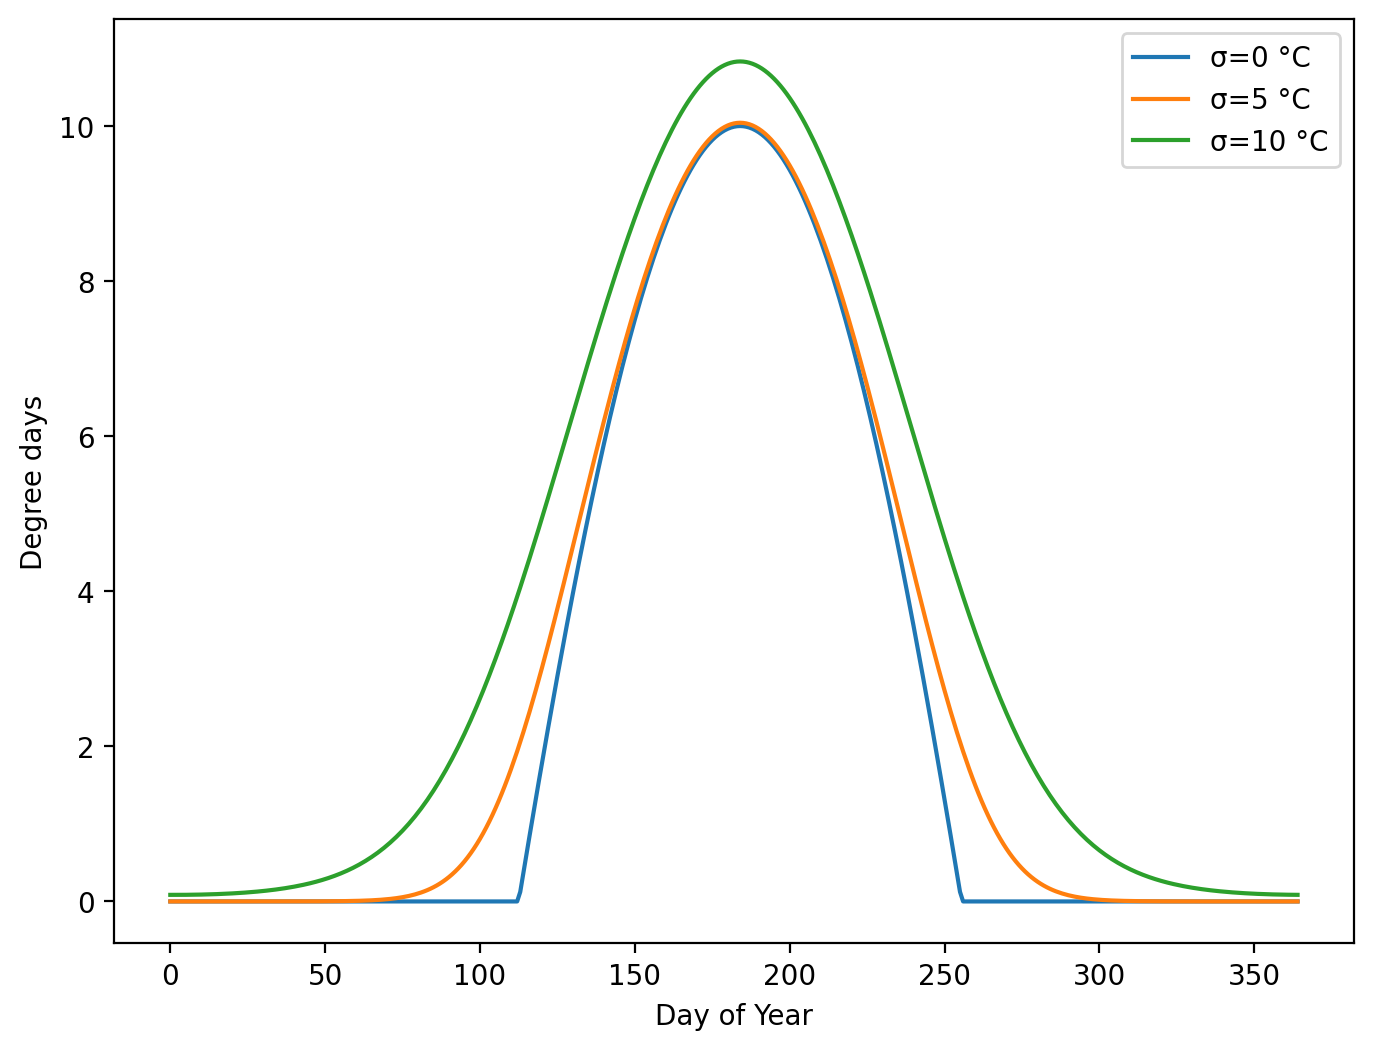

In [8]:
fig, ax = plt.subplots(dpi=200, figsize=(8, 6))
ax.plot(np.roll(annual_pdd_sig0, 184), label="σ=0 °C")
ax.plot(np.roll(annual_pdd, 184), label="σ=5 °C")
ax.plot(np.roll(annual_pdd_sig10, 184), label="σ=10 °C")

ax.set_xlabel("Day of Year")
ax.set_ylabel("Degree days")
ax.legend()


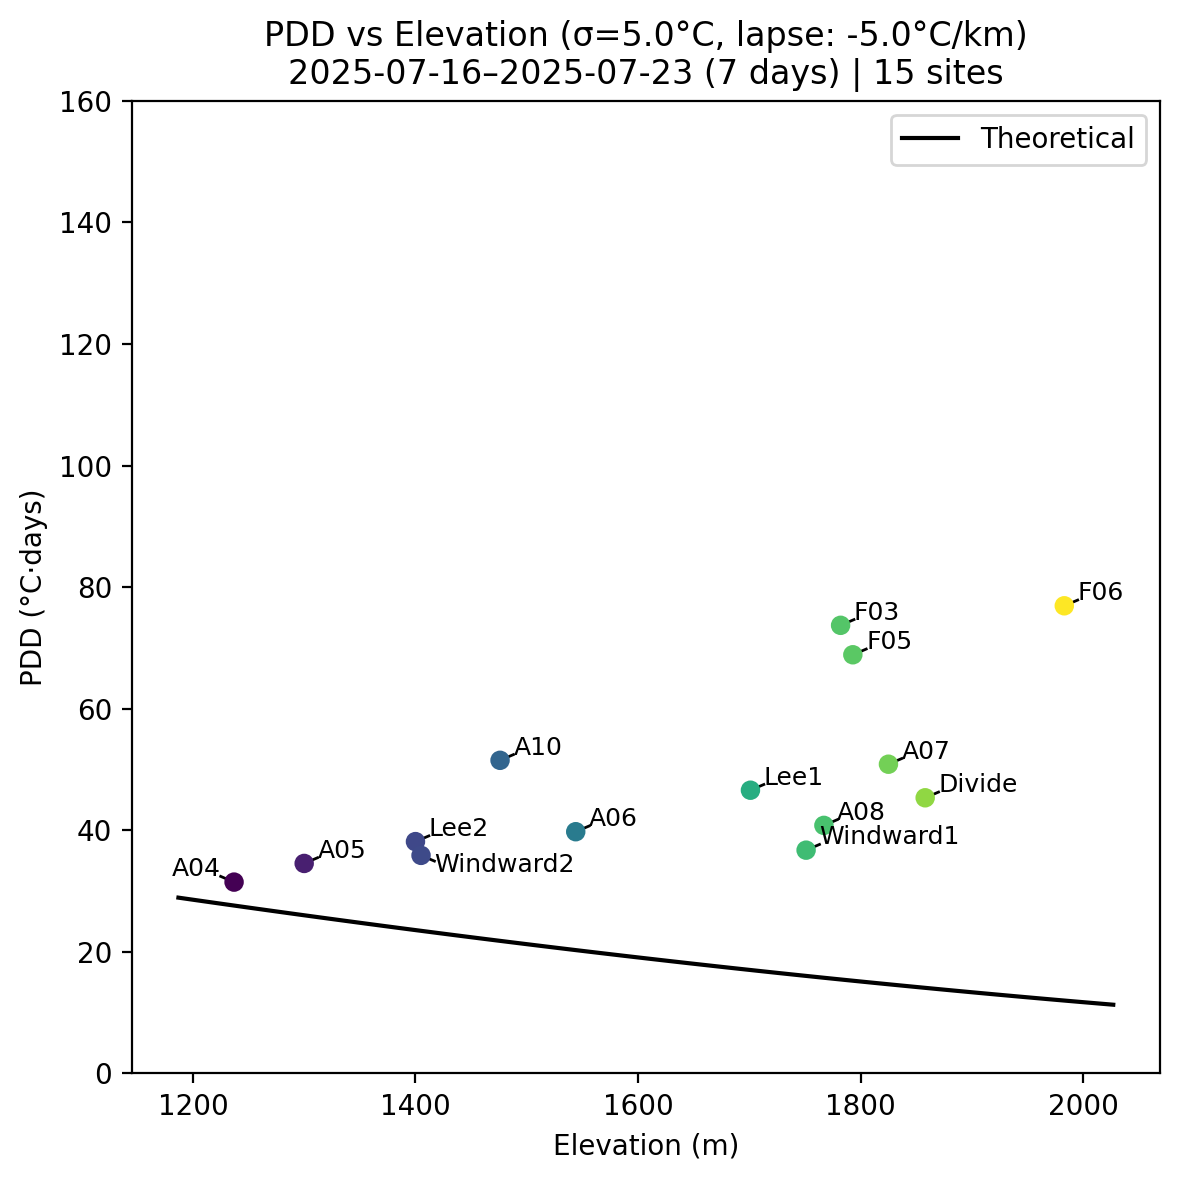

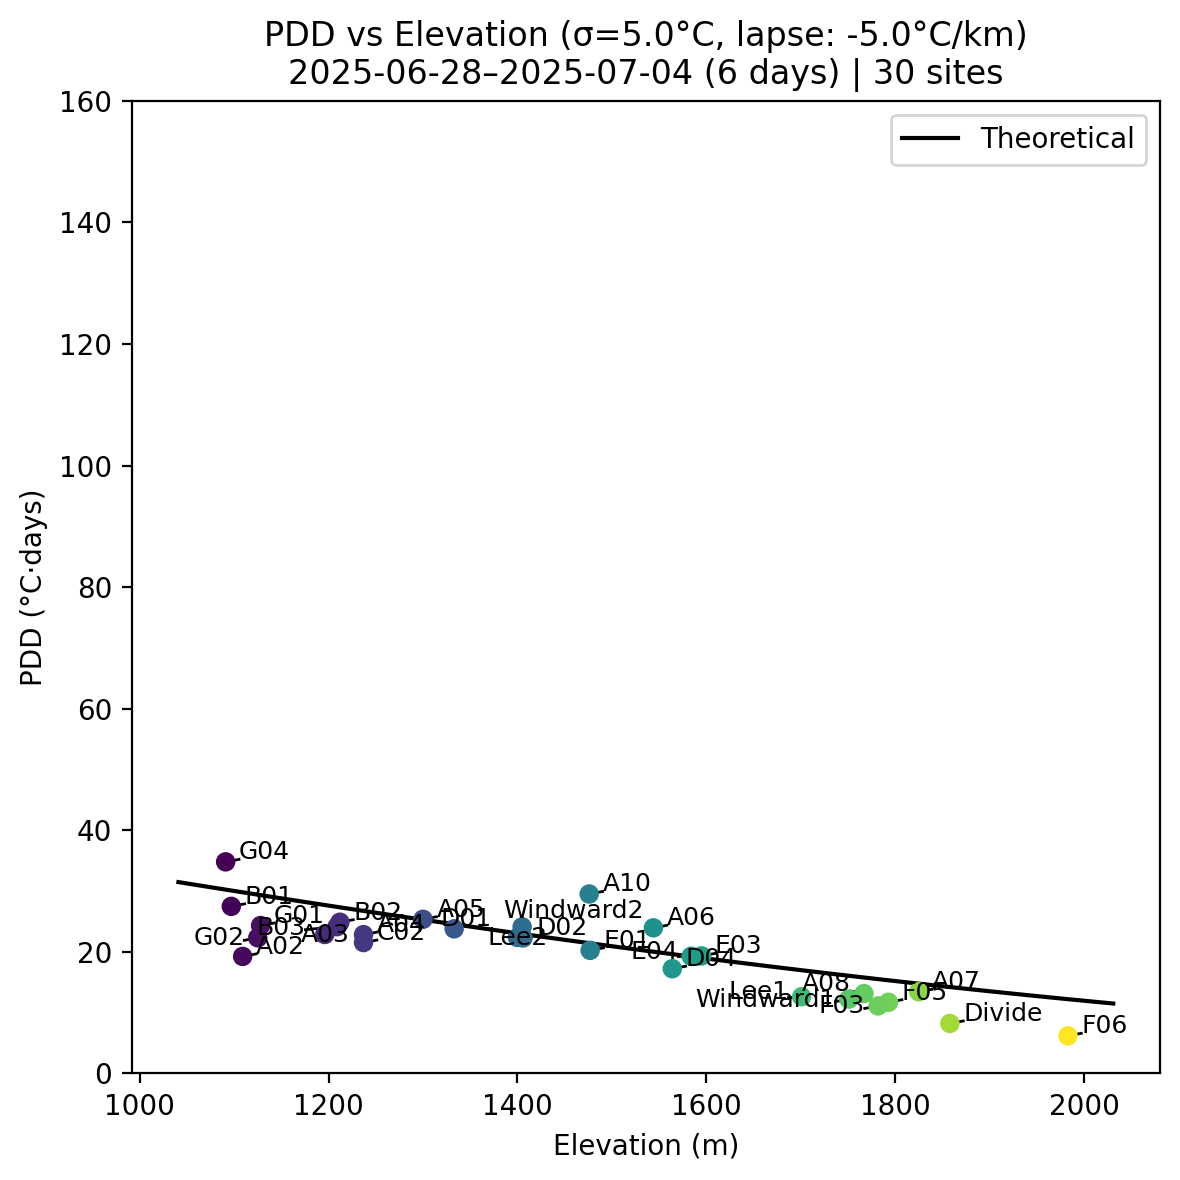

In [9]:
def plot_pdd_vs_elevation_daterange(date_ranges, criterion=SINGLE_CRITERION):
    """
    For each date range: scatter observed PDD vs elevation, with theoretical line.
    Only sites with complete data throughout the date range are included.

    Parameters
    ----------
    date_ranges : list of pd.DatetimeIndex
        e.g. [pd.date_range("2022-07-01", "2022-09-30", freq="15min"), ...]
    criterion : str
        "all", "daylight", or "dual"
    """
    for dr in date_ranges:
        start_str = dr[0].strftime("%Y-%m-%d")
        end_str = dr[-1].strftime("%Y-%m-%d")
        n_days = (dr[-1] - dr[0]).days

        # Slice da to the date range, keep only sites with complete data
        da_window = da.sel(datetime=dr)
        has_data = da_window.notnull().all(dim="datetime")
        da_window = da_window.sel(sensor_idx=has_data)
        da_day_window = da_daylight.sel(datetime=dr).sel(sensor_idx=has_data)

        # Observed PDD using chosen criterion
        if criterion == "dual":
            df_obs = get_overlap_pdd_dual(da_window, da_day_window)
            label, color = (
                f"Dual ({DAY_THRESHOLD}°C day / {NIGHT_THRESHOLD}°C night)",
                "green",
            )
        elif criterion == "all":
            df_obs = get_overlap_pdd(da_window, threshold=0)
            label, color = "All Hours (0°C)", "steelblue"
        else:  # daylight
            df_obs = get_overlap_pdd(da_day_window, threshold=DAY_THRESHOLD)
            label, color = "Daylight Only (0°C)", "orange"

        df_plot = df_obs[["pdd", "elevation"]].dropna()

        elev_range = np.arange(
            int(df_plot.elevation.min()) - 50,
            int(df_plot.elevation.max()) + 50,
            10,
        )
        theo_line = np.array(
            [
                pdd_from_datetimes(
                    dr,
                    T_ma=T_MA_0 + LAPSE_T_MA * e,
                    T_mj=T_MJ_0 + LAPSE_T_MJ * e,
                    sigma=SIGMA,
                )
                for e in elev_range
            ]
        )

        fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
        ax.plot(
            elev_range, theo_line, color="black", lw=1.5, zorder=2, label="Theoretical"
        )
        ax.scatter(
            df_plot.elevation,
            df_plot.pdd,
            c=df_plot.elevation,
            cmap="viridis",
            zorder=3,
        )
        ta.allocate(
            ax,
            df_plot.elevation.values,
            df_plot.pdd.values,
            df_plot.index.tolist(),
            x_scatter=df_plot.elevation.values,
            y_scatter=df_plot.pdd.values,
            textsize=9,
            textcolor="black",
            linecolor="black",
        )
        ax.set_xlabel("Elevation (m)")
        ax.set_ylabel("PDD (°C·days)")
        ax.set_ylim(0, 160)
        ax.set_title(
            f"PDD vs Elevation (σ={SIGMA}°C, lapse: {LAPSE_T_MA * 1000:.1f}°C/km)\n"
            f"{start_str}–{end_str} ({n_days} days) | {da_window.sizes['sensor_idx']} sites"
        )
        ax.legend()
        plt.tight_layout()
        plt.show()


date_ranges = [
    pd.date_range("2025-07-16", "2025-07-23", freq="15min"),
    pd.date_range("2025-06-28", "2025-07-04", freq="15min"),
]
plot_pdd_vs_elevation_daterange(date_ranges)

# Calculate lapse rates

In [10]:
continental_sites = ["Divide", "Lee1", "Lee2", "A08"]  # A10 removed
maritime_sites = ["A04", "A05", "Windward2", "A06", "Windward1", "A07", "Divide"]
# maritime_sites = [
#     site_id for site_id in ds.site_id.values if site_id not in continental_sites
# ]

# Create masks for maritime and continental sites
maritime_mask = ds.site_id.isin(maritime_sites).values
continental_mask = ds.site_id.isin(continental_sites).values

print("Calculating maritime lapse rates...")
# Apply to maritime sites
maritime_slopes, maritime_intercepts = xr.apply_ufunc(
    lapse_rate_ufunc,
    da,
    da.elevation,
    maritime_mask,
    input_core_dims=[["datetime", "sensor_idx"], ["sensor_idx"], []],
    output_core_dims=[["datetime"], ["datetime"]],
    output_dtypes=[float, float],
    dask="forbidden",  # Disable dask for simplicity
)

print("Calculating continental lapse rates...")
# Apply to continental sites
continental_slopes, continental_intercepts = xr.apply_ufunc(
    lapse_rate_ufunc,
    da,
    da.elevation,
    continental_mask,
    input_core_dims=[["datetime", "sensor_idx"], ["sensor_idx"], []],
    output_core_dims=[["datetime"], ["datetime"]],
    output_dtypes=[float, float],
    dask="forbidden",  # Disable dask for simplicity
)

print("Lapse rate calculation completed!")

# %%
# Add the calculated lapse rates and intercepts as data variables to the dataset
print("Adding lapse rate variables to dataset...")

# Create DataArrays with proper coordinates and attributes
maritime_lapse_rate = xr.DataArray(
    maritime_slopes,
    coords={"datetime": da.datetime},
    dims=["datetime"],
    name="maritime_lapse_rate",
    attrs={
        "long_name": "Maritime sites temperature lapse rate",
        "units": "degrees_C/m",
        "description": f"Linear regression slope for temperature vs elevation for maritime sites: {maritime_sites}",
        "sites_included": ", ".join(maritime_sites),
        "calculation_method": "hourly linear regression using scipy.stats.linregress",
    },
)

maritime_intercept = xr.DataArray(
    maritime_intercepts,
    coords={"datetime": da.datetime},
    dims=["datetime"],
    name="maritime_intercept",
    attrs={
        "long_name": "Maritime sites temperature lapse rate intercept",
        "units": "degrees_C",
        "description": f"Linear regression intercept for temperature vs elevation for maritime sites: {maritime_sites}",
        "sites_included": ", ".join(maritime_sites),
        "calculation_method": "hourly linear regression using scipy.stats.linregress",
    },
)

continental_lapse_rate = xr.DataArray(
    continental_slopes,
    coords={"datetime": da.datetime},
    dims=["datetime"],
    name="continental_lapse_rate",
    attrs={
        "long_name": "Continental sites temperature lapse rate",
        "units": "degrees_C/m",
        "description": f"Linear regression slope for temperature vs elevation for continental sites: {continental_sites}",
        "sites_included": ", ".join(continental_sites),
        "calculation_method": "hourly linear regression using scipy.stats.linregress",
    },
)

continental_intercept = xr.DataArray(
    continental_intercepts,
    coords={"datetime": da.datetime},
    dims=["datetime"],
    name="continental_intercept",
    attrs={
        "long_name": "Continental sites temperature lapse rate intercept",
        "units": "degrees_C",
        "description": f"Linear regression intercept for temperature vs elevation for continental sites: {continental_sites}",
        "sites_included": ", ".join(continental_sites),
        "calculation_method": "hourly linear regression using scipy.stats.linregress",
    },
)

# Add to the hourly dataset
ds = da.to_dataset()
ds["maritime_lapse_rate"] = maritime_lapse_rate
ds["maritime_intercept"] = maritime_intercept
ds["continental_lapse_rate"] = continental_lapse_rate
ds["continental_intercept"] = continental_intercept

print("Lapse rate variables added successfully!")
print(f"Dataset variables: {list(ds.data_vars)}")

Calculating maritime lapse rates...
Calculating continental lapse rates...
Lapse rate calculation completed!
Adding lapse rate variables to dataset...
Lapse rate variables added successfully!
Dataset variables: ['temp_c', 'maritime_lapse_rate', 'maritime_intercept', 'continental_lapse_rate', 'continental_intercept']


In [11]:
print(ds)

<xarray.Dataset> Size: 2MB
Dimensions:                 (sensor_idx: 30, datetime: 5502)
Coordinates:
  * sensor_idx              (sensor_idx) int64 240B 0 1 2 3 4 ... 25 26 27 28 29
  * datetime                (datetime) datetime64[ns] 44kB 2025-06-11T16:45:0...
    sensor_id               (sensor_idx) <U8 960B '22133648' ... '22133654'
    site_id                 (sensor_idx) <U9 1kB 'G01' 'D02' ... 'Lee1' 'Divide'
    height                  (sensor_idx) <U2 240B '2m' '2m' '2m' ... '2m' '2m'
    shielding               (sensor_idx) <U10 1kB 'shielded' ... 'shielded'
    sensor_type             (sensor_idx) <U12 1kB 'hobo pendant' ... 'hobo pe...
    sensor_generation       (sensor_idx) <U3 360B 'new' 'new' ... 'new' 'new'
    elevation               (sensor_idx) float64 240B 1.128e+03 ... 1.858e+03
    latitude                (sensor_idx) float64 240B 58.62 58.68 ... 58.86
    longitude               (sensor_idx) float64 240B -134.3 -134.4 ... -134.2
Data variables:
    temp_c       

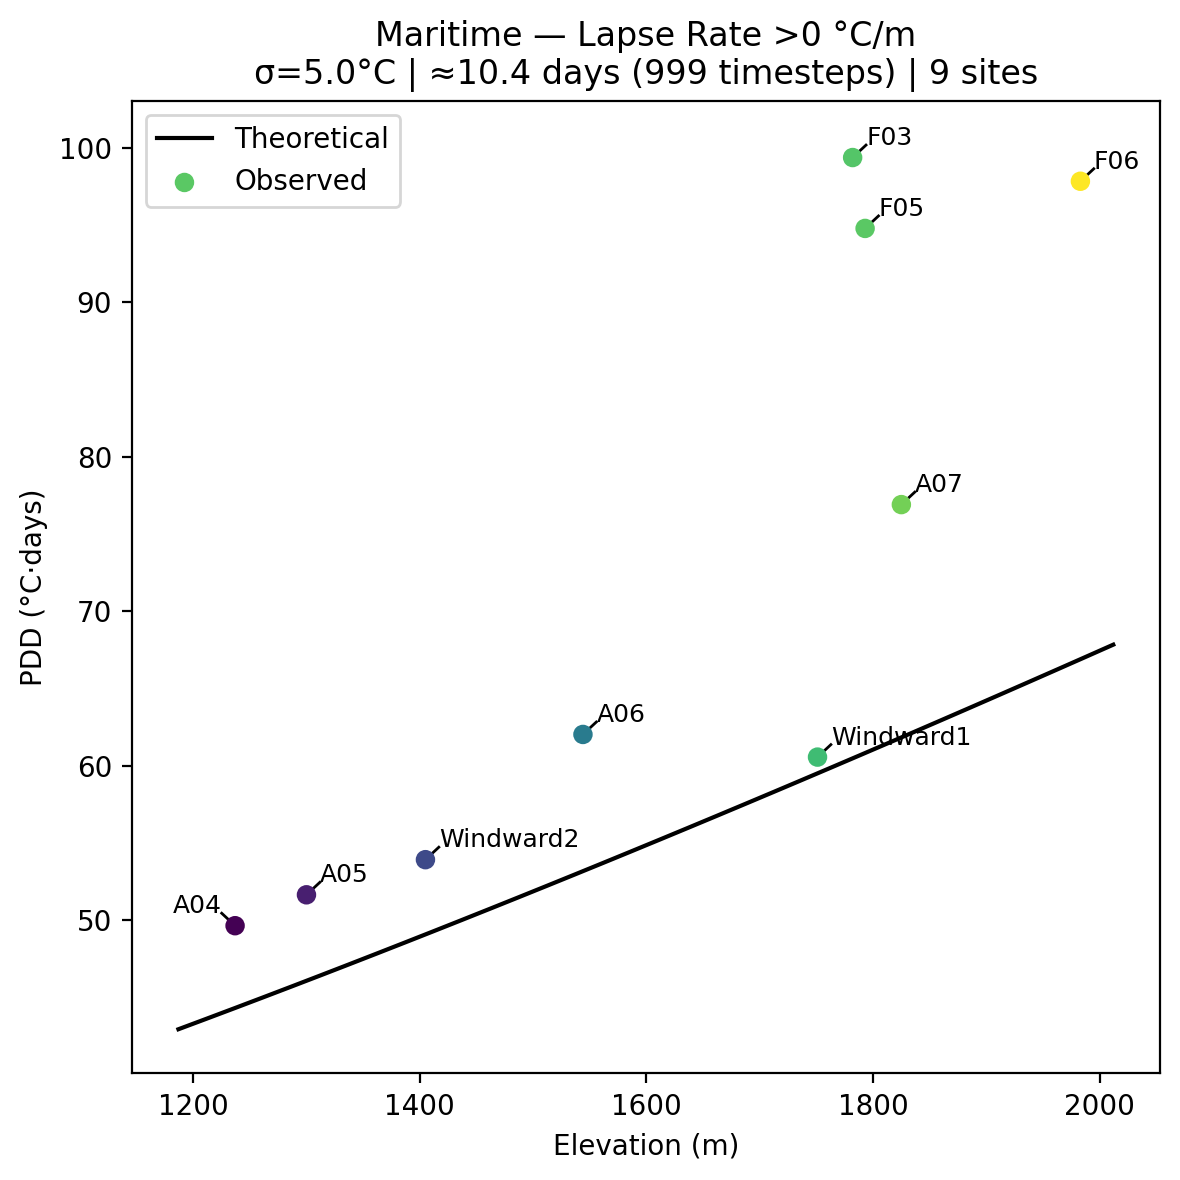

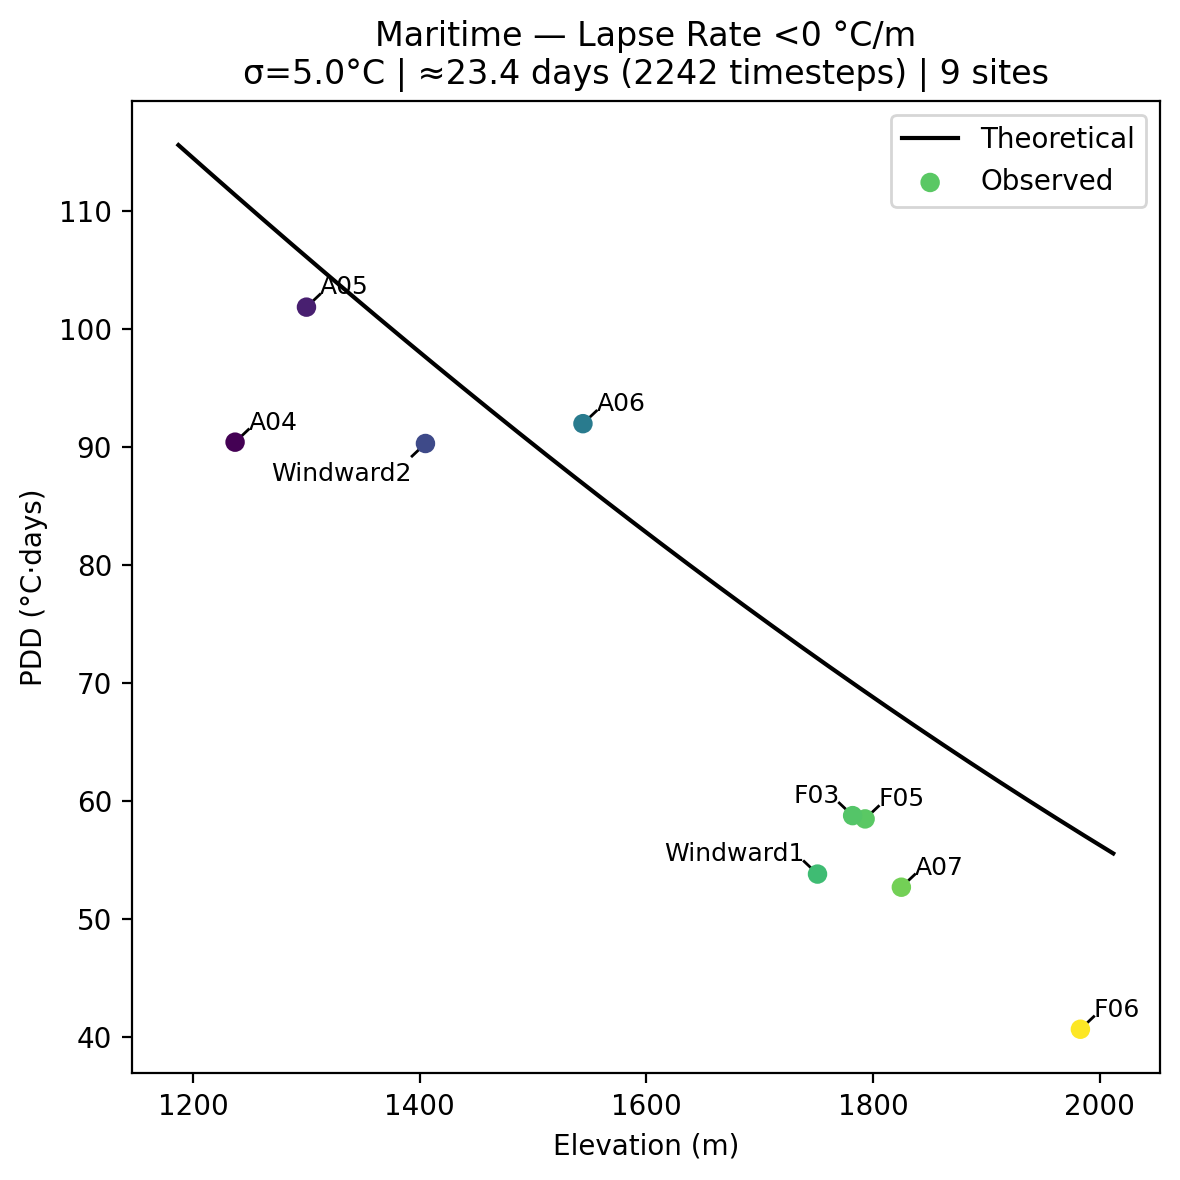

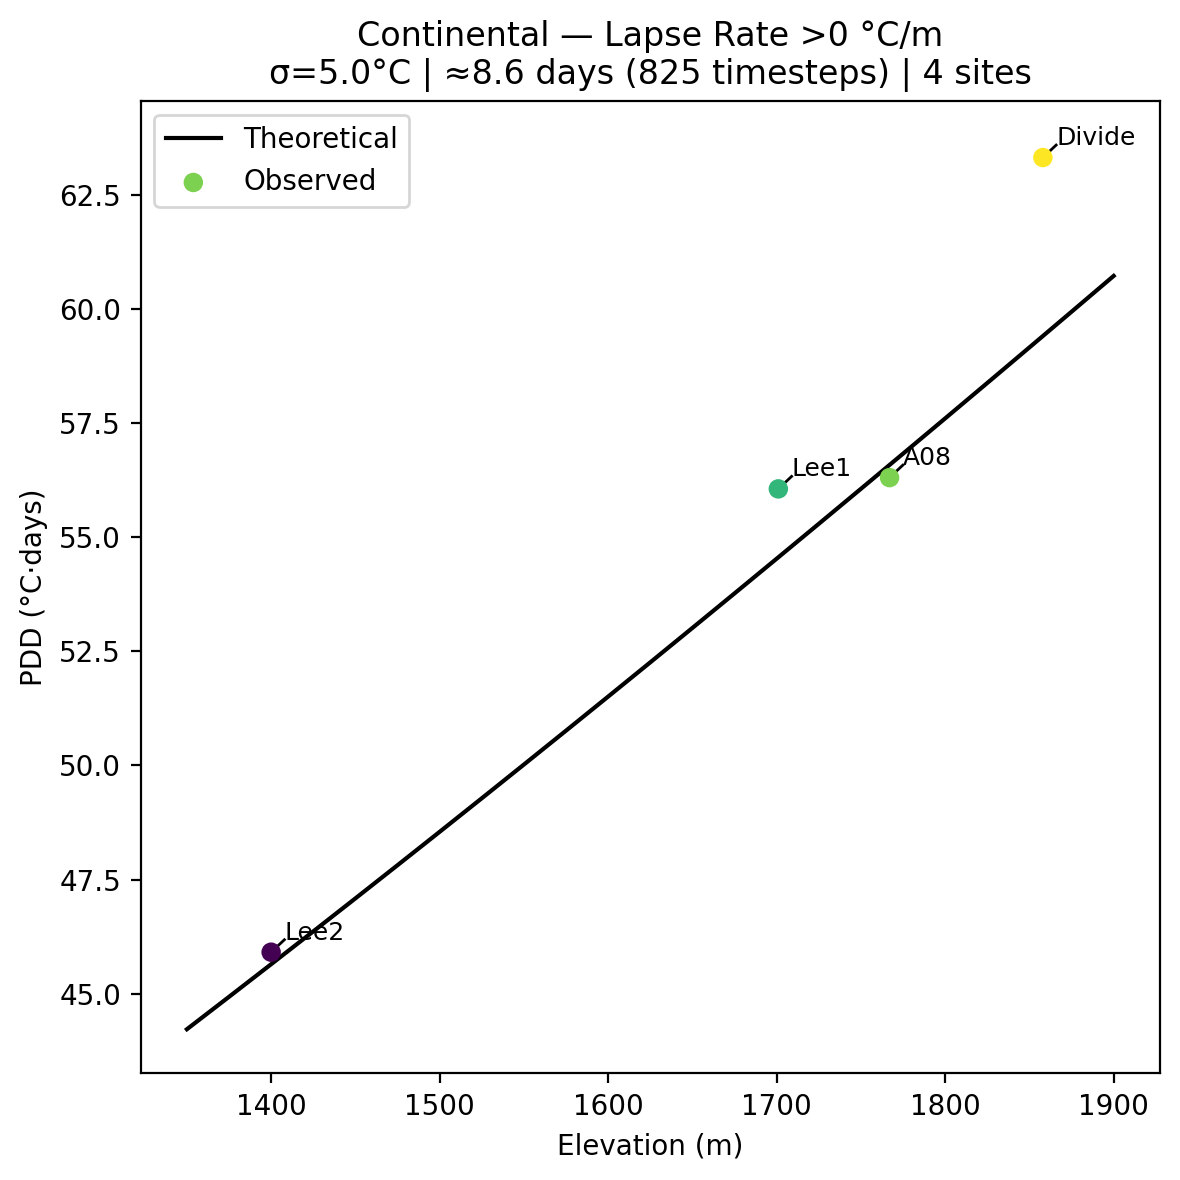

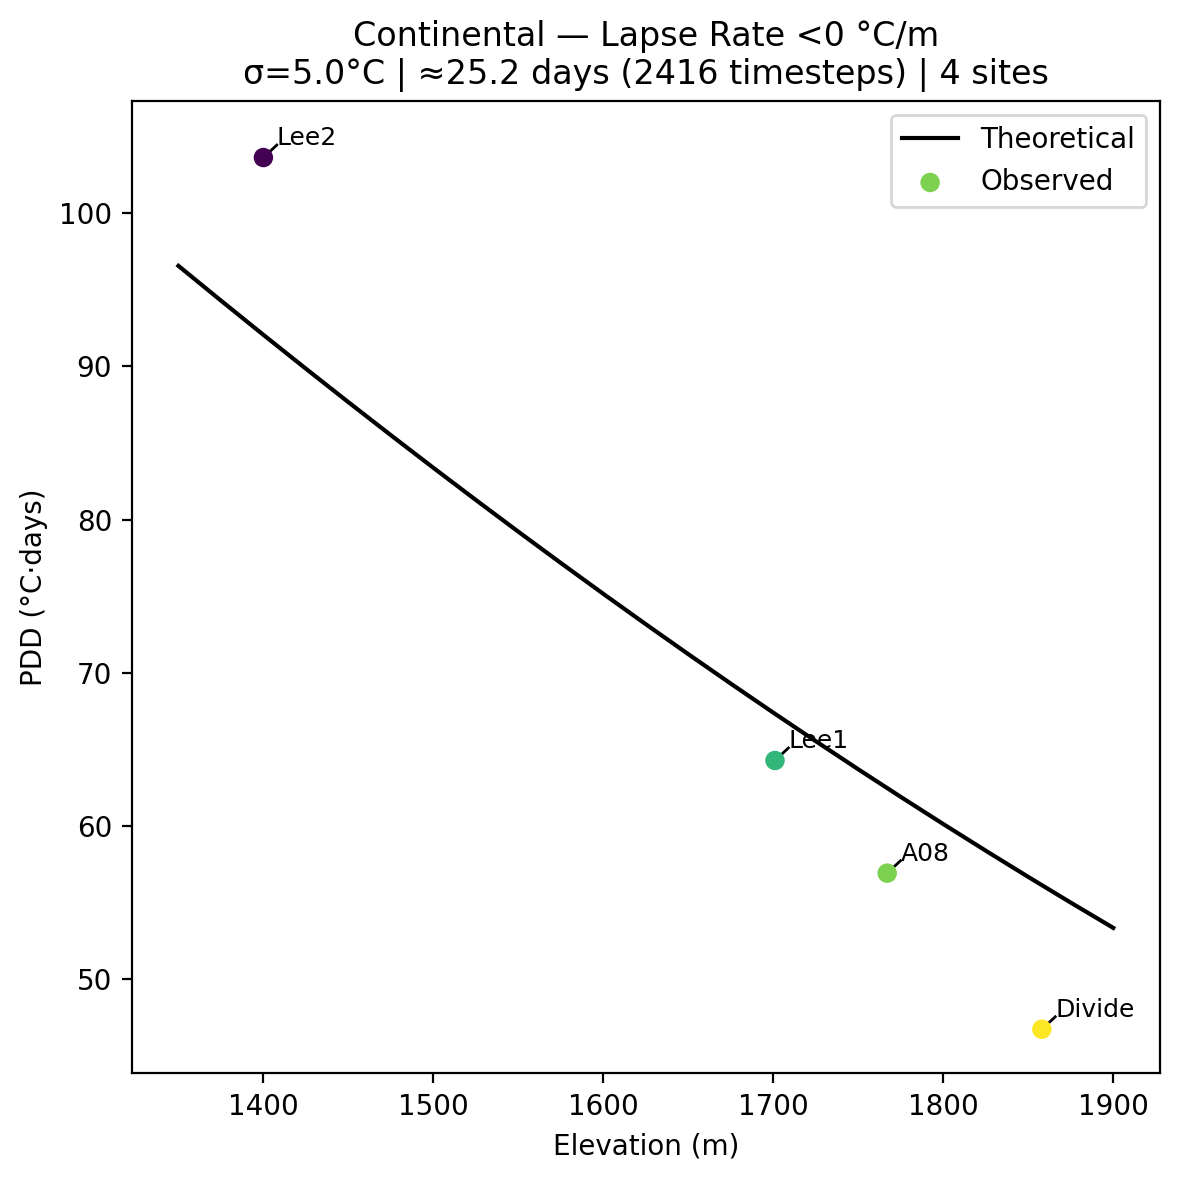

In [30]:
def plot_pdd_lapse_condition(
    ds: xr.Dataset,
    da_p2: xr.DataArray,
    regime: str,
    condition: str,
    continental_sites: list[str],
    maritime_sites: list[str],
    T_MA_0: float,
    T_MJ_0: float,
    LAPSE_T_MA: float,
    LAPSE_T_MJ: float,
    SIGMA: float,
    ax: plt.Axes | None = None,
) -> plt.Figure:
    """
    Plot observed PDD vs elevation with a theoretical line, restricted to
    timesteps where the regime's lapse rate meets *condition*.

    Uses pdd_from_datetimes and sum_observed_pdds internally, so all
    temporal scaling is handled automatically.

    Parameters
    ----------
    ds : xr.Dataset
        Full dataset containing lapse rate variables.
    da_p2 : xr.DataArray
        Temperature DataArray pre-filtered to p2 sensors.
    regime : {'maritime', 'continental'}
        Which sensor group and lapse rate variable to use.
    condition : {'>0', '<0'}
        Lapse rate sign condition to mask on.
    continental_sites, maritime_sites : list of str
        Site ID lists for each regime.
    T_MA_0, T_MJ_0, LAPSE_T_MA, LAPSE_T_MJ, SIGMA : float
        Sinusoidal model parameters.
    ax : plt.Axes, optional
        Axes to plot into.  A new figure is created if None.

    Returns
    -------
    plt.Figure
    """
    # ── 1. Restrict to timesteps where ALL p2 sensors have data ─────────────
    completeness_mask = da_p2.notnull().all(dim="sensor_idx").values
    da_valid = da_p2.isel(datetime=completeness_mask)

    # ── 2. Apply lapse rate condition ────────────────────────────────────────
    lapse_var = f"{regime}_lapse_rate"
    lapse_rate = ds[lapse_var].sel(datetime=da_valid.datetime)

    lr_mask = (lapse_rate > 0).values if condition == ">0" else (lapse_rate < 0).values
    da_masked = da_valid.isel(datetime=lr_mask)

    if da_masked.sizes["datetime"] == 0:
        print(f"No valid timesteps for {regime} {condition}.")
        return None

    # ── 3. Filter to regime sites ────────────────────────────────────────────
    site_ids = maritime_sites if regime == "maritime" else continental_sites
    regime_site_mask = np.isin(da_masked.site_id.values, site_ids)
    da_regime = da_masked.isel(sensor_idx=regime_site_mask)

    # ── 4. Observed PDD ──────────────────────────────────────────────────────
    obs_pdd = sum_observed_pdds(da_regime)

    df_obs = pd.DataFrame(
        {
            "elevation": da_regime.elevation.values,
            "pdd": obs_pdd.values,
        },
        index=da_regime.site_id.values,
    )
    df_obs.index.name = "site_id"

    # ── 5. Theoretical PDD over the same masked datetimes ───────────────────
    masked_dti = pd.DatetimeIndex(da_masked.datetime.values)

    elev_range = np.arange(
        int(df_obs.elevation.min()) - 50,
        int(df_obs.elevation.max()) + 50,
        25,
    )
    theo_line = np.array(
        [
            pdd_from_datetimes(
                masked_dti,
                T_ma=T_MA_0 + LAPSE_T_MA * e,
                T_mj=T_MJ_0 + LAPSE_T_MJ * e,
                sigma=SIGMA,
            )
            for e in elev_range
        ]
    )

    # ── 6. Plot ──────────────────────────────────────────────────────────────
    n_steps = da_masked.sizes["datetime"]
    n_days = n_steps * 15.0 / 1440.0
    cond_label = f"Lapse Rate {condition} °C/m"

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6), dpi=200)
    else:
        fig = ax.figure

    ax.plot(elev_range, theo_line, color="black", lw=1.5, zorder=2, label="Theoretical")
    ax.scatter(
        df_obs.elevation,
        df_obs.pdd,
        c=df_obs.elevation,
        cmap="viridis",
        zorder=3,
        label="Observed",
    )
    ta.allocate(
        ax,
        df_obs.elevation.values,
        df_obs.pdd.values,
        df_obs.index.tolist(),
        x_scatter=df_obs.elevation.values,
        y_scatter=df_obs.pdd.values,
        textsize=9,
        textcolor="black",
        linecolor="black",
    )

    ax.set_xlabel("Elevation (m)")
    ax.set_ylabel("PDD (°C·days)")
    ax.set_title(
        f"{regime.capitalize()} — {cond_label}\n"
        + f"σ={SIGMA}°C | ≈{n_days:.1f} days ({n_steps} timesteps)"
        f" | {len(df_obs)} sites",
    )
    ax.legend()
    plt.tight_layout()
    return fig


# ---------------------------------------------------------------------------
# Convenience wrapper: generate all 4 plots
# ---------------------------------------------------------------------------
def plot_all_lapse_conditions(
    ds: xr.Dataset,
    da_p2: xr.DataArray,
    continental_sites: list[str],
    maritime_sites: list[str],
    T_MA_0: float,
    T_MJ_0: float,
    LAPSE_T_MA: float,
    LAPSE_T_MJ: float,
    SIGMA: float,
    plot_params: dict[tuple[str, str], dict] | None = None,
) -> None:
    """
    Generate all four regime × condition plots.

    Parameters
    ----------
    plot_params : dict, optional
        Overrides for the theoretical line parameters, keyed by
        (regime, condition) tuples.  Any subset of keys may be provided;
        unspecified plots fall back to the global defaults.

        Example::

            plot_params = {
                ("maritime", ">0"): dict(T_MA_0=2.0, SIGMA=3.5),
                ("continental", "<0"): dict(LAPSE_T_MA=-0.006, T_MJ_0=8.0),
            }
    """
    defaults = dict(
        T_MA_0=T_MA_0,
        T_MJ_0=T_MJ_0,
        LAPSE_T_MA=LAPSE_T_MA,
        LAPSE_T_MJ=LAPSE_T_MJ,
        SIGMA=SIGMA,
    )
    plot_params = plot_params or {}

    for regime in ("maritime", "continental"):
        for condition in (">0", "<0"):
            # Merge: start from global defaults, then apply any per-plot overrides
            params = {**defaults, **plot_params.get((regime, condition), {})}

            fig = plot_pdd_lapse_condition(
                ds=ds,
                da_p2=da_p2,
                regime=regime,
                condition=condition,
                continental_sites=continental_sites,
                maritime_sites=maritime_sites,
                **params,
            )
            if fig is not None:
                plt.show()


# ── Site lists ────────────────────────────────────────────────────────────────
continental_sites = ["Divide", "Lee1", "Lee2", "A08"]
maritime_sites = [s for s in ds.site_id.values if s not in continental_sites]

# ── p2 DataArray ──────────────────────────────────────────────────────────────
da_p2, _ = get_period_arrays("p3")

# ── Per-plot parameter overrides ──────────────────────────────────────────────
plot_params = {
    ("maritime",     ">0"): dict(T_MA_0=-20, T_MJ_0=0, LAPSE_T_MA=0.0035, LAPSE_T_MJ=0.0035),
    ("maritime",     "<0"): dict(T_MA_0=-5, T_MJ_0=10, LAPSE_T_MA=-0.0045, LAPSE_T_MJ=-0.0045),
    ("continental",  ">0"): dict(T_MA_0=-20, T_MJ_0=0, LAPSE_T_MA=0.004, LAPSE_T_MJ=0.004),
    ("continental",  "<0"): dict(T_MA_0=-5, T_MJ_0=10, LAPSE_T_MA=-0.005, LAPSE_T_MJ=-0.005),
}

# ── Run all 4 plots ───────────────────────────────────────────────────────────
plot_all_lapse_conditions(
    ds=ds,
    da_p2=da_p2,
    continental_sites=continental_sites,
    maritime_sites=maritime_sites,
    T_MA_0=T_MA_0,
    T_MJ_0=T_MJ_0,
    LAPSE_T_MA=LAPSE_T_MA,
    LAPSE_T_MJ=LAPSE_T_MJ,
    SIGMA=SIGMA,
    plot_params=plot_params,
)